# Homework 3  
## Regression models

# <p style="text-align: right;"> &#9989; Joel Chaple. </p>
# <p style="text-align: right;"> &#9989; nasajoel2032. </p>

# Goal for this homework assignment
By now, you have learned a bit about regression models. In this assignment, you will practice:

* Using branches in Git
* Performing linear regression
* Performing multiple regression
* Performing logistic regression
* Creating a project timeline

**This assignment is due by 11:59 pm on Friday, November 7th.** It should be uploaded into the "Homework Assignments" submission folder for Homework 3.  Submission instructions can be found at the end of the notebook. **There are 90 standard points possible in this assignment, including points for Git commits/pushes. The distribution of points can be found in the section headers**.


---
<a id="toc"></a>

## Table of contents

* [Part 1: Git branch](#part1) (6 points)

* [Part 2: Loading the datasets](#part2) (9 points)

* [Part 3: Simple linear regression](#part3) (17 points)

* [Part 4: Multiple regression](#part4) (27 points)

* [Part 5: Logistic regression](#part5) (22 points)

* [Part 6: Project planning](#part6) (5 points)

* [Part 7: Assignment wrap-up](#part7) (4 points)


##### Run this cell below before moving on:

In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split


sns.set_context("talk")

---
[Back to ToC](#toc)
<a name="part1"></a>
# Part 1: Git Branch (6 points) 


You're going to add this assignment to the `cmse202-f25-turnin` repository you created so that you can track your progress on the assignment and preserve the final version that you turn in. You will do this by performing the tasks 1.1 - 1.6 below.

**Important**: Double-check you've added your Professor and your TA as collaborators to your "turnin" repository (you should have done this in the HW01 assignment).

**Also important**: Make sure that the version of this notebook that you are working on is the same one that you just added to your repository! If you are working on a different copy of the notebook, **none of your changes will be tracked**!

**&#9989; Question 1.1 (1 point)**: Navigate to your `cmse202-f25-turnin` **local** repository and create a new directory called `hw-03`. In the cell below put the command(s) you used to do this.

``` bash
cd CMSE202/repositories/cmse202-f25-turnin/
mkdir hw-03
```

**&#9989; Question 1.2 (1 point)**: Move this notebook into that **new directory** in your repository, but **do not** add or commit it to your repository yet. Put the command(s) you used to do this in the cell below.

``` bash
cd ~
mv HW3.ipynb CMSE202/repositories/cmse202-f25-turnin/hw-03
```

**&#9989; Question 1.3 (1 point)**: Create a **new branch** called `hw03_branch` (The Day 16 PCA and ICA content has information on how to do this). Put the command(s) you used to do this in the cell below.

``` bash
cd CMSE202/repositories/cmse202-f25-turnin/
git branch hw03_branch
```

**&#9989; Question 1.4 (1 point)**: "Check out" the new branch (so that you'll be working on that branch). Put the command(s) you used to do this in the cell below.

``` bash
git checkout hw03_branch
```

**&#9989; Question 1.5 (1 point)**:  Double check to make sure you are actually on that branch. Put the command(s) you used to do this in the cell below.

``` bash
git branch
```

**&#9989; Question 1.6 (1 point)**: Once you're certain you're working on your new branch, add this notebook to your repository, then make a commit and push it to GitHub. You may need to use `git push origin hw03_branch` to push your new branch to GitHub. Put the command(s) you used to do this in the cell below.

``` bash
git add hw-03/HW3.ipynb 
git commit -m "Add HW03 to hw03 branch"
git push origin hw03_branch 
```

---
If everything went as intended, the file should now show up on your GitHub account in the "`cmse202-f25-turnin`" repository inside the `hw-03` directory that you just created within the new branch `hw03-branch`.

Periodically, **you'll be asked to commit your changes to the repository and push them to the remote GitHub location**. Of course, you can always commit your changes more often than that, if you wish.  It can be good to get into a habit of committing your changes any time you make a significant modification, or when you stop working on the problems for a bit.

&#9989; **Do this:  Remember to do every Git commit/push mentioned throughout the assignment!**


---
[Back to ToC](#toc)
<a name="part2"></a>
# Part 2: Loading the dataset. (9 points)

In this section, you will work with data from the [California Housing Prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices) dataset. The dataset includes all block groups in California from the 1990 Census. On average, each block group contains approximately 1,425.5 individuals residing in a geographically compact area. As expected, the size of each area varies inversely with population density. Distances between block group centroids are calculated using latitude and longitude coordinates. Block groups with zero values for either the independent or dependent variables were excluded from the analysis. The final dataset consists of 20,640 observations across 9 variables.

Our goal is to use ordinary least squares to design regression models to fit the median house value in a California census district, given eight features. We will examine a simple linear model using all the provided features, a reduced linear model that only uses a subset of the features, and a multiple regression model.

<u>Reference:</u> Pace, R. Kelley, and Ronald Barry. "Sparse spatial autoregressions." Statistics & Probability Letters 33.3 (1997): 291-297. 

&#9989;  **Question 2.1 (1 points)**: **Do This:** Download the file `housing.csv` from the link below, and save it into the same directory as your notebook. **Then, in the cell below, put the command line command(s) you used to download the file.** If you did not use a command line tool to download the file, write down the command(s) that would have downloaded the file.

`https://raw.githubusercontent.com/msu-cmse-courses/cmse202-F22-data/main/data/housing.csv`

``` bash
curl -O https://raw.githubusercontent.com/msu-cmse-courses/cmse202-F22-data/main/data/housing.csv
mv housing.csv hw-03
```

&#9989;  **Question 2.2 (2 points)**: Next, load the data using Pandas and display the first **20** rows.

In [3]:
house = pd.read_csv('housing.csv')
house.head(20)

,longitude,latitude,housing_median_age,avg_rooms,avg_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,6.984127,1.023810,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,6.238137,0.971880,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,8.288136,1.073446,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,5.817352,1.073059,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,6.281853,1.081081,565,259,3.8462,342200,NEAR BAY
5,-122.25,37.85,52,4.761658,1.103627,413,193,4.0368,269700,NEAR BAY
6,-122.25,37.84,52,4.931907,0.951362,1094,514,3.6591,299200,NEAR BAY
7,-122.25,37.84,52,4.797527,1.061824,1157,647,3.1200,241400,NEAR BAY
8,-122.26,37.84,42,4.294118,1.117647,1206,595,2.0804,226700,NEAR BAY
9,-122.25,37.84,52,4.970588,0.990196,1551,714,3.6912,261100,NEAR BAY


<font color = blue > You should notice that the DataFrame has a non-numerical feature called "ocean_proximity". There are also a few rows with `NaN` values, although you may not see them in the few rows that were displayed. We will not use the "ocean_proximity" column or any of the rows with `NaN` values in this assignment. </font>

&#9989;  **Question 2.3 (2 points)**: **Do This:** **Drop the "ocean_proximity" column from the dataframe, and drop all the rows with `NaN` values.**

In [4]:
house_clean = house.drop(columns=['ocean_proximity'])
house_clean = house_clean.dropna()
house_clean

,longitude,latitude,housing_median_age,avg_rooms,avg_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,6.984127,1.023810,322,126,8.3252,452600
1,-122.22,37.86,21,6.238137,0.971880,2401,1138,8.3014,358500
2,-122.24,37.85,52,8.288136,1.073446,496,177,7.2574,352100
3,-122.25,37.85,52,5.817352,1.073059,558,219,5.6431,341300
4,-122.25,37.85,52,6.281853,1.081081,565,259,3.8462,342200
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,5.045455,1.133333,845,330,1.5603,78100
20636,-121.21,39.49,18,6.114035,1.315789,356,114,2.5568,77100
20637,-121.22,39.43,17,5.205543,1.120092,1007,433,1.7000,92300
20638,-121.32,39.43,18,5.329513,1.171920,741,349,1.8672,84700


&#9989;  **Question 2.4 (2 points)**: How many rows did you end up dropping from this data set? What total percentage of data was removed?

In [5]:
rows_dropped = len(house) - len(house_clean)
percent_dropped = (rows_dropped / len(house)) * 100

print(f"Rows dropped: {rows_dropped}")
print(f"Data dropped: {percent_dropped}%")

Rows dropped: 207
Data dropped: 1.002906976744186%


&#9989;  **Question 2.5 (2 points)**: Look at the [Kaggle website](https://www.kaggle.com/datasets/camnugent/california-housing-price) for this dataset is hosted on Kaggle. What do the columns `longitude` and `latitude` represent?

- Longitude: left to right coordinates of the location (west to east) for geographic pinging
- Latitude: vertical coordinates of the location (north to south) for geographic pinging

---
### &#128721; STOP
**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your local `git` repository using the commit message "Part 2 complete", and push the changes to GitHub.

---
<a name="part3"></a>
[Back to ToC](#toc)

# Part 3: One Variable Linear Regression (17 points)

In this part, we'll perform some one-variable linear regression analysis on the California Housing dataset we just downloaded.

 &#9989; **Question 3.1 (4 points)**: Using the `OLS()` method in `statsmodels.api`, make a simple linear regression model that predicts "median_house_value" using "median_income" as the independent variable. Be sure to use the `add_constant()` method to add a column of ones to the DataFrame before using the `OLS()` method so that your linear model includes a constant term.

In [6]:
X = house['median_income']
X = sm.add_constant(X)
y = house['median_house_value']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.473
Method:                 Least Squares   F-statistic:                 1.856e+04
Date:                Fri, 07 Nov 2025   Prob (F-statistic):               0.00
Time:                        21:18:23   Log-Likelihood:            -2.6325e+05
No. Observations:               20640   AIC:                         5.265e+05
Df Residuals:                   20638   BIC:                         5.265e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          4.509e+04   1322.872     34.082

&#9989; **Question 3.2 (2 points):** Comment on the fit of your model. What are you using to judge the fit?

The model has a decent fit, accounting for roughly 47% of the variability in house values, while considering only median income. This means that statistically, these two variables alone have a good correlation or connection to one another. Other summary values, such as the Durbin-Watson statistic, suggest that it could possibly benefit from being modeled differently.

&#9989; **Question 3.3 (4 points):** Plot the scatter plot of your independent and dependent data and also plot the line predicted by the regression. Include descriptive labels, titles, and legends as appropriate.

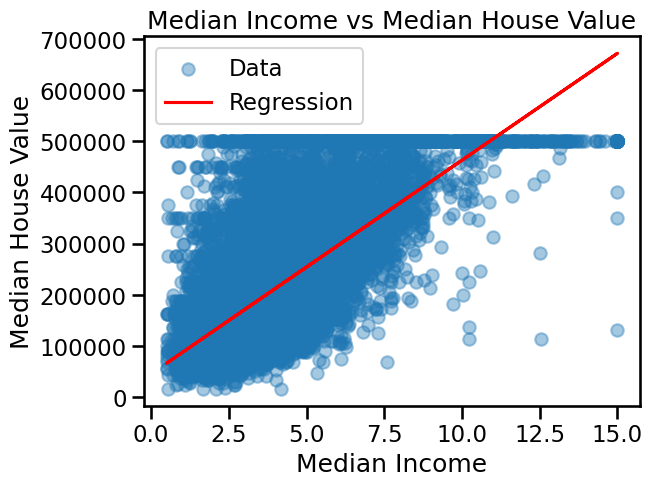

In [7]:
plt.scatter(house['median_income'], house['median_house_value'], label='Data', alpha=.4)
plt.plot(house['median_income'], model.predict(X), color='r', label='Regression')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Median Income vs Median House Value')
plt.legend()
plt.show()

&#9989; **Question 3.3 (2 points):** From your plot, you will notice that the dataset includes a lot of entires with a median housing value of \$500,000. Let us investigate if this affects our regression analysis or not. 

**Do this:** Now mask the housing dataset to exclude all data points with a median house value of at least $500,000. 

In [8]:
mask = house[house['median_house_value'] < 500000]
mask

,longitude,latitude,housing_median_age,avg_rooms,avg_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,6.984127,1.023810,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,6.238137,0.971880,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,8.288136,1.073446,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,5.817352,1.073059,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,6.281853,1.081081,565,259,3.8462,342200,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,5.045455,1.133333,845,330,1.5603,78100,INLAND
20636,-121.21,39.49,18,6.114035,1.315789,356,114,2.5568,77100,INLAND
20637,-121.22,39.43,17,5.205543,1.120092,1007,433,1.7000,92300,INLAND
20638,-121.32,39.43,18,5.329513,1.171920,741,349,1.8672,84700,INLAND


&#9989; **Question 3.4 (4 points):** Now make a simple linear regression model that predicts "median_house_value" using "median_income" as the independent variable, on this new data subset. Be sure to use the `add_constant()` method to include a constant term in your model.

In [9]:
masked_X = sm.add_constant(mask['median_income'])
masked_y = mask['median_house_value']
maskedmodel = sm.OLS(masked_y, masked_X).fit()
print(maskedmodel.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.418
Model:                            OLS   Adj. R-squared:                  0.418
Method:                 Least Squares   F-statistic:                 1.412e+04
Date:                Fri, 07 Nov 2025   Prob (F-statistic):               0.00
Time:                        21:18:24   Log-Likelihood:            -2.4819e+05
No. Observations:               19648   AIC:                         4.964e+05
Df Residuals:                   19646   BIC:                         4.964e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          4.505e+04   1345.113     33.489

&#9989; **Question 3.5 (4 points):** Make a scatter plot of your independent and dependent data, and also plot the line predicted by the new regression model above. Include descriptive labels, titles, and legends as appropriate.

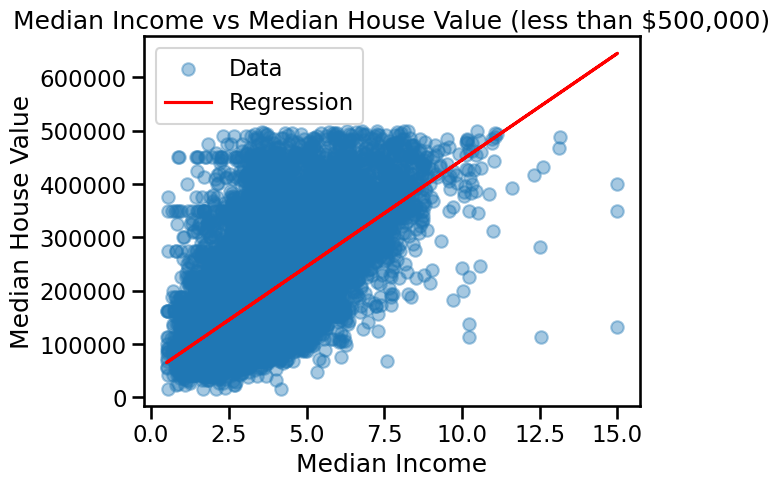

In [10]:
plt.scatter(mask['median_income'], mask['median_house_value'], label='Data', alpha=.4)
predicted_values = maskedmodel.predict(masked_X)
plt.plot(mask['median_income'], predicted_values, color='r',label='Regression')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Median Income vs Median House Value (less than $500,000)')
plt.legend()
plt.show()

&#9989; **Question 3.6 (1 point):** Comment on the fit of your last model. What are you using to judge the fit?

The model still has a decent fit, but not as much as before, accounting for roughly 42% of the variability in house values, while considering only median income. This means that statistically, the $500,000 houses actually strengthened the correlation, rather than weakening it.

---
### &#128721; STOP
**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your local `git` repository using the commit message "Part 3 complete", and push the changes to GitHub.

---
<a name="part4"></a>
[Back to ToC](#toc)


# Part 4: Multiple Regression (27 points)
In this part, we will explore multivariable regression on the same California Housing dataset from part 3. Reload the dataset that includes median house values of $500,000.

&#9989; **Question 4.1 (5 points)**: Using the `OLS()` method in `statsmodels.api`, make a multiple regression model that predicts "median_house_value" using the other variables, and display the `.summary()` of that process. Remember that you may need to use the `add_constant()` method to make sure `OLS` fits a general line $y = k+ax_1 + bx_2 +... +hx_8$, with $k$ constant, to the data instead of a line through the origin $y = ax_1 + bx_2 +... +hx_8$. 

In [44]:
mask = house[house['median_house_value'] < 500000]

X = mask.drop(columns=['median_house_value'])
X = X.select_dtypes(include=['number'])
X = X.replace([np.inf, -np.inf], np.nan).dropna()
X = sm.add_constant(X)
y = mask.loc[X.index, 'median_house_value']  

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     3723.
Date:                Fri, 07 Nov 2025   Prob (F-statistic):               0.00
Time:                        22:08:46   Log-Likelihood:            -2.4189e+05
No. Observations:               19448   AIC:                         4.838e+05
Df Residuals:                   19439   BIC:                         4.839e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -3.263e+06   5.77

&#9989;  **Question 4.2 (4 points)**: Answer the following two questions: 

1. What is the R-squared value you got? 

2. Based on your R-squared value, what does it tell you about the regression fit, and how the model fits the data?

- 0.605
- The regression fit does a decent job at modeling and predicting certain results, but there are still some that it is missing and resulting in inaccurate predictions.

&#9989;  **Question 4.3 (2 points)**: 
Based on the output of the OLS summary, which of these features (variables) appears to be "significant" in predicting the "median_house_value"?

All of the features are significant due to their extremely low (0 or approximately 0) P values.

&#9989;  **Question 4.4 (4 points)**: In the output of the OLS summary, you should have seen a note that says something like 

"_The condition number is large, [[number]]. This might indicate that there are strong multicollinearity or other numerical problems._" 

Multicollinearity is a statistical phenomenon where some of the features in a model can be linearly predicted using some of the other features in the model. In other words, the features in the model are somewhat redundant. Hence, even if each feature may be deemed significant, it may still be possible to form a "reduced" model using a smaller number of features. 

---
**Do This:** Design a second linear model that uses only **three** of the eight variables to predict the "median_house_value", and fits the data comparably well as the first linear model you designed in Question 4.2. You can choose this subset either by trial and error or by any other method you'd like.

In [45]:
mask = house[house['median_house_value'] < 500000]
X = mask[['avg_rooms', 'median_income', 'population']]
X = sm.add_constant(X)
y = mask['median_house_value']

reduced_model = sm.OLS(y, X).fit()
print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.430
Model:                            OLS   Adj. R-squared:                  0.430
Method:                 Least Squares   F-statistic:                     4935.
Date:                Fri, 07 Nov 2025   Prob (F-statistic):               0.00
Time:                        22:08:47   Log-Likelihood:            -2.4799e+05
No. Observations:               19648   AIC:                         4.960e+05
Df Residuals:                   19644   BIC:                         4.960e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          6.497e+04   1733.567     37.475

&#9989;  **Question 4.5 (2 points)**: How did your reduced linear model fit the data compared to the full linear model you created in Question 4.1? Give some quantitative justification for this answer.

The newer and smaller linear model had an R-squared value of 0.430, whereas the original linear model had an R-squared value of 0.605. This means that although it loses accuracy, it offers better differentiation between the impact of the three variables compared to the higher accuracy model, albeit with less tangible insight. 

&#9989;  **Question 4.6 (5 points)**: Now that you have your reduced model, make a heat map showing the correlations between the different variables (similar to what we did on Day 14). Be sure to include a legend!

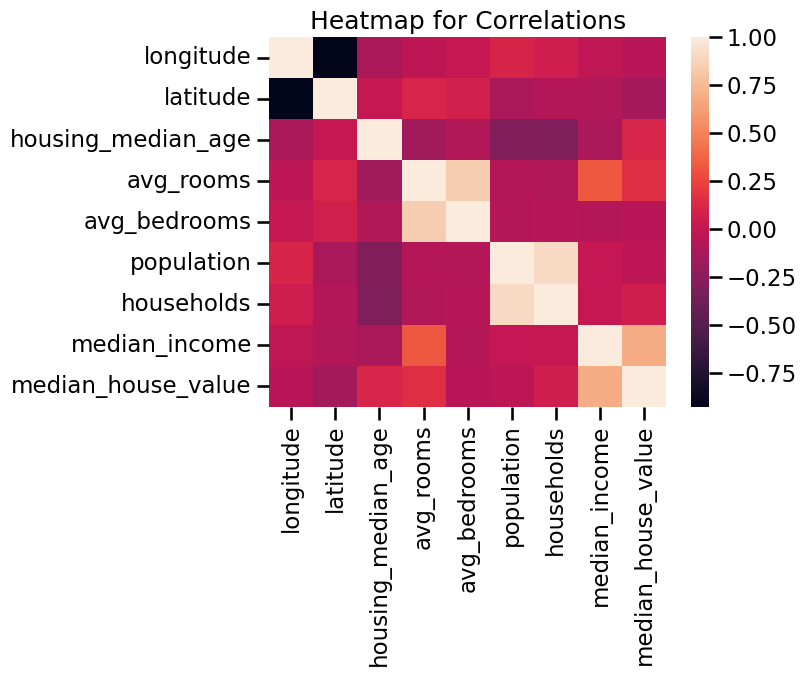

In [46]:
corr_house = house.select_dtypes(include=['float64', 'int64'])
corr = corr_house.corr()
sns.heatmap(corr)
plt.title('Heatmap for Correlations')
plt.show()

&#9989;  **Question 4.7 (1 point)**: You should find that there isn’t much overlap between the high-correlation variables in the heat map and the variables you used in your (reduced)  model, the opposite of what we found on Day 14. Explain why this is the case.

This could be the case because the reduced model uses variables that each has their own grand impact on house values while other variables with high correlations make the model less accurate.

&#9989;  **Question 4.8 (3 points)**: Create three `.graphics.plot_regress_exog` figures, each one using one of the three features in your reduced model as the independent variable, to examine the fit to the data. Pay attention to the top two plots in each instance: the fitted values figure and the residual plot. 

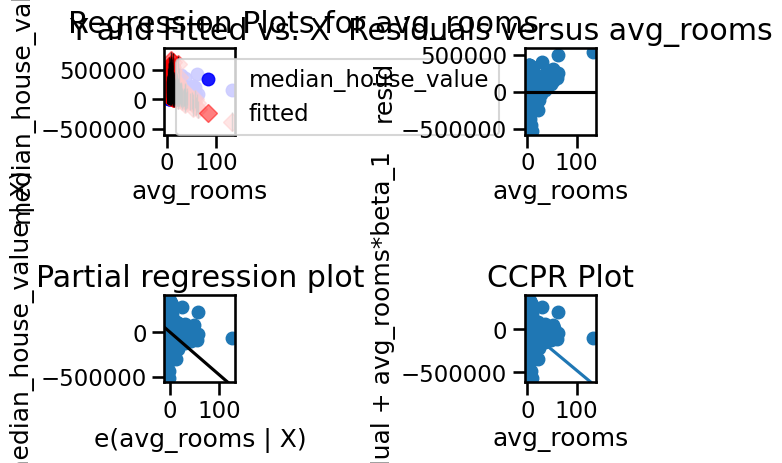

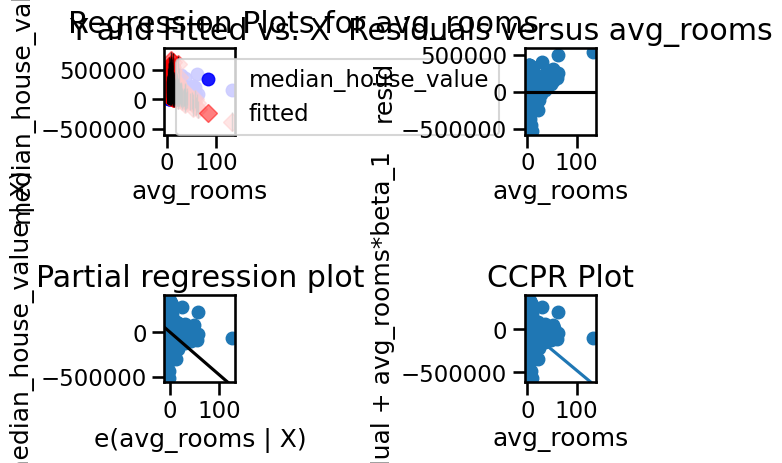

In [47]:
model = sm.OLS(y, X).fit()
sm.graphics.plot_regress_exog(model, 'avg_rooms')

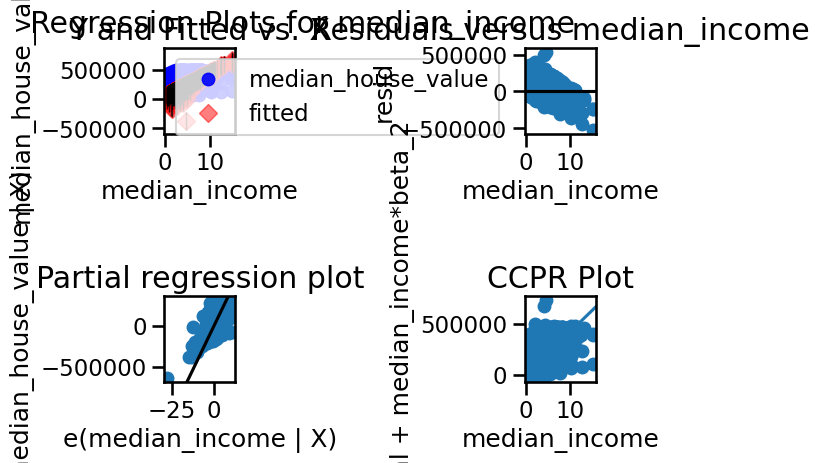

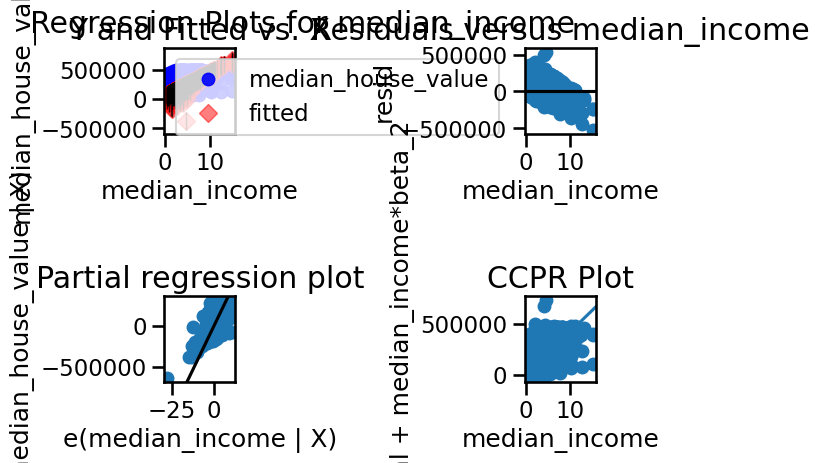

In [48]:
sm.graphics.plot_regress_exog(model, 'median_income')

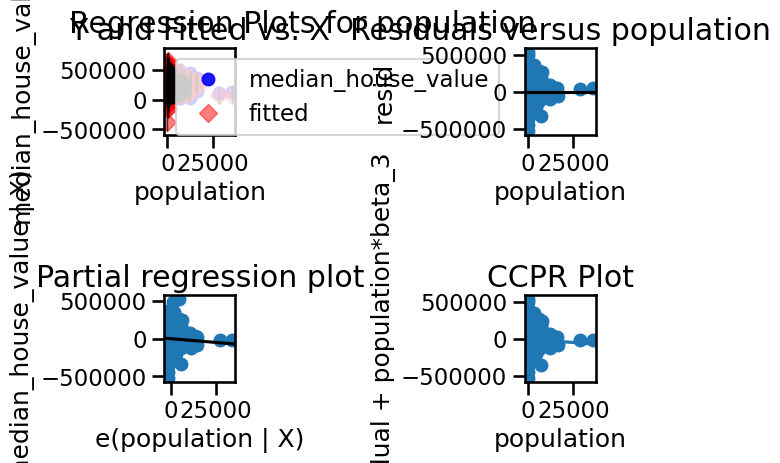

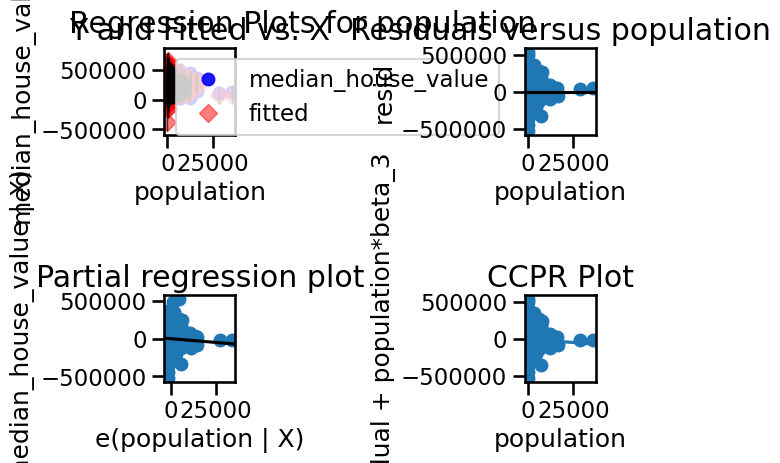

In [49]:
sm.graphics.plot_regress_exog(model, 'population')

&#9989;  **Question 4.9 (1 point)**: Now use some online resource to help you make sense of these residual plots. Describe the trends that you see. Be as detailed as possible. Is there heteroscedasticity? Is there constant variance? Are there any signs of non-linearity? These are a few questions you might ask yourself or try to answer to make sense of the residual plots.

There is heteroscedasticity and also nonlinearity, suggesting that the linear model doesn't have a great fit. The variance is not constant so the model is not too accurate.

---
### &#128721; STOP
**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your local `git` repository using the commit message "Part 4 complete", and push the changes to GitHub.

---
<a name="part5"></a>
[Back to ToC](#toc)

## Part 5. Logistic Regression (22 points)

In this part of the homework, you will work with data from an unknown source. Our goal is to use logistic regression to identify who is more likely to buy merchandise from ads on social networks.

&#9989;  **Question 5.1 (3 points)**: **Do This:**

1. Download the dataset and write the command you used in the next cell

`https://raw.githubusercontent.com/msu-cmse-courses/cmse202-F22-data/main/HW/Homework_4/ads.csv`
    
2. Load the data in this file into a `Pandas` dataframe
3. Display the first **five** rows of the dataframe. 

In [ ]:
# Put the command to download the data here 


In [ ]:
# Put your code for reading in the dataset here


As you can see the dataset has only few columns. The first columns is not useful since it is a unique identifier. The second column could be useful, however, we need numbers instead of strings. Hence we are left only with the last three columns. `Age` and `EstimatedSalary` will be our features while `Purchased` will be our labels 

&#9989;  **Question 5.2 (3 points)**: 

1. **Do This:** Drop the first and second columns of the dataset    
2. **Do This:** Divided the rest of the dataset into a train and a test dataset using `train_test_split` function of `scikit-learn`. The test dataset should be 25% of the original data


In [ ]:
# Put your code here


&#9989;  **Question 5.3 (4 points)**: 

1. **Do This:** Use the `Logit` class to perform Logistic regression on your training dataset (don't forget to add the constant).
2. **Do This:** Print the results of your model


In [ ]:
# Put your code here

&#9989;  **Question 5.4 (2 points)**: Do you think this is a good fit? Explain your answer


<font size=+3>&#9998;</font> _Put your answer here:_

&#9989;  **Question 5.5 (4 points)**: Use the above model to make predictions on the test dataset. Remember that the `Logit` model returns continuous values from 0 to 1 while you need two discrete values. Then use the function `accuracy_score` from `scikit-learn` to see how good your model is.

In [ ]:
# Put your code here

&#9989;  **Question 5.6 (1 point)**: Does the accuracy score change your opinion of the goodness of your model?


<font size=+3>&#9998;</font> _Put your answer here:_

&#9989;  **Question 5.7 (5 points)**: Does your model improve if you re-introduce the `Gender` column? Since the column is made of strings, replace `Male` with 0 and `Female` with 1. Is `Gender` an informative feature?
Explain your answers.

In [ ]:
# Put your code here

<font size=+3>&#9998;</font> _Put your explanation here:_

---
### &#128721; STOP
**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your local `git` repository using the commit message "Part 5 complete", and push the changes to GitHub.

---
[Back to ToC](#toc)

<a name="part5"></a>
## Part 6. Setting a project timeline. (5 points)

You should know which project you will be working on with your group by now. You and your group will be presenting this project during the last week of class (November 24th-December 2nd).  Come up with a project timeline with specific goals/checkpoints to meet as this deadline approaches.  The ability to set project timelines is a very useful skill to have professionally. You can create this timeline yourself, as a group, or you may ask generative AI to try and make a timeline for you. Try to, in the very least, create weekly checkpoints (~3).

<font size=+3>&#9998;</font> Put your timeline here:

---
<a name="conclusion"></a>
[Back to ToC](#toc)

## Part 7: Assignment wrap-up (4 points)


**7.1:** (1 point) Have you put **your name** and **GitHub username** at the top of your notebook?

**7.2:** (3 points) Now that you've finished your new "development" on your 202 turn-in repo, you can merge your work back into your `main` branch.

**&#9989; Do the following**:

1. Switch back to your `main` branch. 
2. Merge your `hw03_branch` with your `main` branch. 
3. Finally, push the changes to GitHub.

**NOTE:** The grader will be able to see your commit messages and whether you pushed the repo at this stage, if everything has gone as planned. Double-check that things look correct on **GitHub** before you submit this notebook to **D2L**.

---
## Congratulations, you're done!

Submit this assignment by uploading it to the course D2L web page.  Go to the "Homework Assignments" folder, find the dropbox link for Homework 3, and upload it there.

&#169; Copyright 2025,  Department of Computational Mathematics, Science and Engineering at Michigan State University